In [1]:
import pandas as pd

from pathlib import Path

p = Path.cwd()
data_path = p / '..' / 'data' / 'Loan_approval_data_2025.csv'
data = pd.read_csv(data_path, header=0)

In [2]:
data.head(6)

,customer_id,age,occupation_status,years_employed,annual_income,credit_score,credit_history_years,savings_assets,current_debt,defaults_on_file,delinquencies_last_2yrs,derogatory_marks,product_type,loan_intent,loan_amount,interest_rate,debt_to_income_ratio,loan_to_income_ratio,payment_to_income_ratio,loan_status
0,CUST100000,40,Employed,17.2,25579,692,5.3,895,10820,0,0,0,Credit Card,Business,600,17.02,0.423,0.023,0.008,1
1,CUST100001,33,Employed,7.3,43087,627,3.5,169,16550,0,1,0,Personal Loan,Home Improvement,53300,14.10,0.384,1.237,0.412,0
2,CUST100002,42,Student,1.1,20840,689,8.4,17,7852,0,0,0,Credit Card,Debt Consolidation,2100,18.33,0.377,0.101,0.034,1
3,CUST100003,53,Student,0.5,29147,692,9.8,1480,11603,0,1,0,Credit Card,Business,2900,18.74,0.398,0.099,0.033,1
4,CUST100004,32,Employed,12.5,63657,630,7.2,209,12424,0,0,0,Personal Loan,Education,99600,13.92,0.195,1.565,0.522,1
5,CUST100005,32,Employed,13.4,32015,570,7.3,253,1120,0,0,2,Credit Card,Personal,37000,22.92,0.035,1.156,0.385,0


In [ ]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 20 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   customer_id              50000 non-null  str    
 1   age                      50000 non-null  int64  
 2   occupation_status        50000 non-null  str    
 3   years_employed           50000 non-null  float64
 4   annual_income            50000 non-null  int64  
 5   credit_score             50000 non-null  int64  
 6   credit_history_years     50000 non-null  float64
 7   savings_assets           50000 non-null  int64  
 8   current_debt             50000 non-null  int64  
 9   defaults_on_file         50000 non-null  int64  
 10  delinquencies_last_2yrs  50000 non-null  int64  
 11  derogatory_marks         50000 non-null  int64  
 12  product_type             50000 non-null  str    
 13  loan_intent              50000 non-null  str    
 14  loan_amount              50000 no

In [ ]:
data['occupation_status'].unique()

<StringArray>
['Employed', 'Student', 'Self-Employed']
Length: 3, dtype: str

In [ ]:
data['defaults_on_file'].unique()

array([0, 1])

In [ ]:
data['derogatory_marks'].unique()

array([0, 2, 1, 3, 4])

In [ ]:
data['product_type'].unique()

<StringArray>
['Credit Card', 'Personal Loan', 'Line of Credit']
Length: 3, dtype: str

In [ ]:
data['loan_intent'].unique()

<StringArray>
[          'Business',   'Home Improvement', 'Debt Consolidation',
          'Education',           'Personal',            'Medical']
Length: 6, dtype: str

In [ ]:
print(f"Total row count: {len(data)}")

Total row count: 50000


In [ ]:
loans_awarded = data.loc[data['loan_status']==1]
loan_intents = loans_awarded['loan_intent'].unique()
for intent in loan_intents:
    print(f"{intent} loans: {len(loans_awarded.loc[loans_awarded['loan_intent']==intent])}")

Business loans: 3312
Debt Consolidation loans: 1802
Education loans: 6841
Home Improvement loans: 3989
Personal loans: 7560
Medical loans: 4019


In [ ]:
loan_types = loans_awarded['product_type'].unique()
for loan_type in loan_types:
    print(f"{loan_type}: {len(loans_awarded.loc[loans_awarded['product_type']==loan_type])}")

Credit Card: 13770
Personal Loan: 8417
Line of Credit: 5336


In [ ]:
# Understand the break down of loan type per loan intent
# Equivalent to: SELECT loan_intent, product_type, COUNT(*) GROUP BY loan_intent, product_type
pd.crosstab(loans_awarded['loan_intent'], loans_awarded['product_type'])

product_type,Credit Card,Line of Credit,Personal Loan
loan_intent,,,
Business,1691,632,989
Debt Consolidation,985,345,472
Education,3310,1325,2206
Home Improvement,2025,754,1210
Medical,2029,788,1202
Personal,3730,1492,2338


In [ ]:
# Seems most loans are awarded as credit cards. Let's see the interest rate of credit card loans
cc_interest_rate = loans_awarded.loc[loans_awarded['product_type']=='Credit Card', 'interest_rate']
print("Statistics")
print(f"Lowest rate: {cc_interest_rate.min()}")
print(f"Average rate: {cc_interest_rate.mean():.2f}")
print(f"Heighest rate: {cc_interest_rate.max()}")

Statistics
Lowest rate: 14.0
Average rate: 18.37
Heighest rate: 23.0


In [ ]:
# Total amount of loan provided with credit cards and as fraction of total loans
total_loan = loans_awarded['loan_amount'].sum()
total_loan_cc = loans_awarded.loc[loans_awarded['product_type']=='Credit Card', 'loan_amount'].sum()

print(f"Total CC loans: {total_loan_cc}")
print(f"Percentage of CC loans: {total_loan_cc * 100 / total_loan:.2f}%")

Total CC loans: 400115500
Percentage of CC loans: 44.83%


### Predict loan status

In [2]:
y = data['loan_status']
X = data.drop(['loan_status', 'customer_id'], axis=1)

In [10]:
print(f"Loan status labels: {y.unique()}")
print("All available features")
print(X.info())

Loan status labels: [1 0]
All available features
<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   age                      50000 non-null  int64  
 1   occupation_status        50000 non-null  str    
 2   years_employed           50000 non-null  float64
 3   annual_income            50000 non-null  int64  
 4   credit_score             50000 non-null  int64  
 5   credit_history_years     50000 non-null  float64
 6   savings_assets           50000 non-null  int64  
 7   current_debt             50000 non-null  int64  
 8   defaults_on_file         50000 non-null  int64  
 9   delinquencies_last_2yrs  50000 non-null  int64  
 10  derogatory_marks         50000 non-null  int64  
 11  product_type             50000 non-null  str    
 12  loan_intent              50000 non-null  str    
 13  loan_amount              50000 non-nul

In [11]:
print(X['occupation_status'].unique())
print(X['product_type'].unique())
print(X['loan_intent'].unique())

<StringArray>
['Employed', 'Student', 'Self-Employed']
Length: 3, dtype: str
<StringArray>
['Credit Card', 'Personal Loan', 'Line of Credit']
Length: 3, dtype: str
<StringArray>
[          'Business',   'Home Improvement', 'Debt Consolidation',
          'Education',           'Personal',            'Medical']
Length: 6, dtype: str


In [12]:
# numerical columns
for col in X.columns:
    if X[col].dtype in ['float64', 'int64']:
        print(X[col].agg(['min', 'max', 'mean']))

min     18.00000
max     70.00000
mean    34.95706
Name: age, dtype: float64
min      0.000000
max     39.900000
mean     7.454868
Name: years_employed, dtype: float64
min      15000.00000
max     250000.00000
mean     50062.89204
Name: annual_income, dtype: float64
min     348.00000
max     850.00000
mean    643.61482
Name: credit_score, dtype: float64
min      0.000000
max     30.000000
mean     8.168274
Name: credit_history_years, dtype: float64
min          0.0000
max     300000.0000
mean      3595.6194
Name: savings_assets, dtype: float64
min         60.00000
max     163344.00000
mean     14290.44222
Name: current_debt, dtype: float64
min     0.00000
max     1.00000
mean    0.05348
Name: defaults_on_file, dtype: float64
min     0.00000
max     9.00000
mean    0.55464
Name: delinquencies_last_2yrs, dtype: float64
min     0.00000
max     4.00000
mean    0.14764
Name: derogatory_marks, dtype: float64
min        500.000
max     100000.000
mean     33041.874
Name: loan_amount, dtype: f

Experiment 1
Disregard all string columns: employement type, product type, and loan intent.
Normalize most of the numerical cols, except for defaults on file, delinquencies in last 2 years, derogatory marks, debt to income ratio, loan to income ratio, and payment to incom ratio.
Baseline: Logistic regression

In [3]:
# Keep a numeric-only baseline, but avoid overwriting the full feature matrix
X_num = X.drop(['occupation_status', 'product_type', 'loan_intent'], axis=1)

In [4]:
from sklearn.model_selection import train_test_split

# Baseline split on numeric-only feature set
X_train, X_test, y_train, y_test = train_test_split(
    X_num, y, test_size=0.2, random_state=3, stratify=y
)

In [27]:
print(X_train.shape)
print(X_test.shape)

(40000, 15)
(10000, 15)


In [23]:
print(X_train['defaults_on_file'].agg(['min', 'max']))
print(X_train['delinquencies_last_2yrs'].agg(['min', 'max', 'mean']))
print(X_train['derogatory_marks'].agg(['min', 'max', 'mean']))
print(X_train['interest_rate'].agg(['min', 'max', 'mean']))
print(X_train['debt_to_income_ratio'].agg(['min', 'max', 'mean']))
print(X_train['loan_to_income_ratio'].agg(['min', 'max', 'mean']))
print(X_train['payment_to_income_ratio'].agg(['min', 'max', 'mean']))

min    0
max    1
Name: defaults_on_file, dtype: int64
min     0.00000
max     9.00000
mean    0.55505
Name: delinquencies_last_2yrs, dtype: float64
min     0.000000
max     4.000000
mean    0.147125
Name: derogatory_marks, dtype: float64
min      6.000000
max     23.000000
mean    15.503932
Name: interest_rate, dtype: float64
min     0.00200
max     0.80000
mean    0.28579
Name: debt_to_income_ratio, dtype: float64
min     0.008000
max     2.001000
mean    0.703783
Name: loan_to_income_ratio, dtype: float64
min     0.003000
max     0.667000
mean    0.234589
Name: payment_to_income_ratio, dtype: float64


In [28]:
X_train.columns

Index(['age', 'years_employed', 'annual_income', 'credit_score',
       'credit_history_years', 'savings_assets', 'current_debt',
       'defaults_on_file', 'delinquencies_last_2yrs', 'derogatory_marks',
       'loan_amount', 'interest_rate', 'debt_to_income_ratio',
       'loan_to_income_ratio', 'payment_to_income_ratio'],
      dtype='str')

In [5]:
# Let's start with MinMaxScaler for selected numerical columns
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression

col_list_to_trs = ['age', 'years_employed', 'annual_income', 'credit_score', 'credit_history_years', 'savings_assets', 'current_debt', 'interest_rate']

numerical_transformer = Pipeline([
    ('scaler', MinMaxScaler())
])

# IMPORTANT: Keep remaining columns (ratios/flags) instead of silently dropping them
preprocessor = ColumnTransformer(
    transformers=[
        ('numeric_trs', numerical_transformer, col_list_to_trs),
    ],
    remainder='passthrough'
 )

In [6]:
clf = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('classifier', LogisticRegression(max_iter=500))
    ]
)

clf.fit(X_train, y_train)
print(f"Model score: {clf.score(X_test, y_test):.4f}")

Model score: 0.8376


/home/akalanka-galappaththi/PythonProjects/CreditRisk/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 500 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=500).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [7]:
# Lets try a bit complex model like SVC and see if that improves
from sklearn.svm import SVC

clf = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('classifier', SVC(gamma='auto'))
    ]
)

clf.fit(X_train, y_train)
print(f"Model score: {clf.score(X_test, y_test):.4f}")

Model score: 0.6919


### Experiment 2
Use all available features with targeted feature engineering and robust preprocessing.

In [8]:
from sklearn.compose import make_column_selector as selector
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report

# Recreate full feature matrix for this experiment
X_full = data.drop(['loan_status', 'customer_id'], axis=1)

# Light feature engineering based on ratios and risk interactions
X_full = X_full.copy()
X_full['income_after_debt'] = X_full['annual_income'] - X_full['current_debt']
X_full['debt_x_dti'] = X_full['current_debt'] * X_full['debt_to_income_ratio']
X_full['rate_x_lti'] = X_full['interest_rate'] * X_full['loan_to_income_ratio']

Xf_train, Xf_test, yf_train, yf_test = train_test_split(
    X_full, y, test_size=0.2, random_state=3, stratify=y
)

numeric_features = selector(dtype_include=['int64', 'float64'])(Xf_train)
categorical_features = selector(dtype_include=['object'])(Xf_train)

numeric_preprocessor = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_preprocessor = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor_full = ColumnTransformer(
    transformers=[
        ('num', numeric_preprocessor, numeric_features),
        ('cat', categorical_preprocessor, categorical_features),
    ]
)

In [9]:
# Logistic Regression with richer preprocessing
clf_lr_full = Pipeline(
    steps=[
        ('preprocessor', preprocessor_full),
        ('classifier', LogisticRegression(max_iter=2000, class_weight='balanced'))
    ]
)

clf_lr_full.fit(Xf_train, yf_train)
pred_lr = clf_lr_full.predict(Xf_test)
proba_lr = clf_lr_full.predict_proba(Xf_test)[:, 1]

print(f"Full LR accuracy: {accuracy_score(yf_test, pred_lr):.4f}")
print(f"Full LR ROC-AUC: {roc_auc_score(yf_test, proba_lr):.4f}")
print(classification_report(yf_test, pred_lr))

# SVC with richer preprocessing
clf_svc_full = Pipeline(
    steps=[
        ('preprocessor', preprocessor_full),
        ('classifier', SVC(kernel='rbf', C=2.0, gamma='scale', probability=True, class_weight='balanced'))
    ]
)

clf_svc_full.fit(Xf_train, yf_train)
pred_svc = clf_svc_full.predict(Xf_test)
proba_svc = clf_svc_full.predict_proba(Xf_test)[:, 1]

print(f"Full SVC accuracy: {accuracy_score(yf_test, pred_svc):.4f}")
print(f"Full SVC ROC-AUC: {roc_auc_score(yf_test, proba_svc):.4f}")
print(classification_report(yf_test, pred_svc))

Full LR accuracy: 0.8897
Full LR ROC-AUC: 0.9626
              precision    recall  f1-score   support

           0       0.87      0.89      0.88      4495
           1       0.91      0.89      0.90      5505

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000

Full SVC accuracy: 0.9137
Full SVC ROC-AUC: 0.9752
              precision    recall  f1-score   support

           0       0.90      0.91      0.90      4495
           1       0.93      0.92      0.92      5505

    accuracy                           0.91     10000
   macro avg       0.91      0.91      0.91     10000
weighted avg       0.91      0.91      0.91     10000



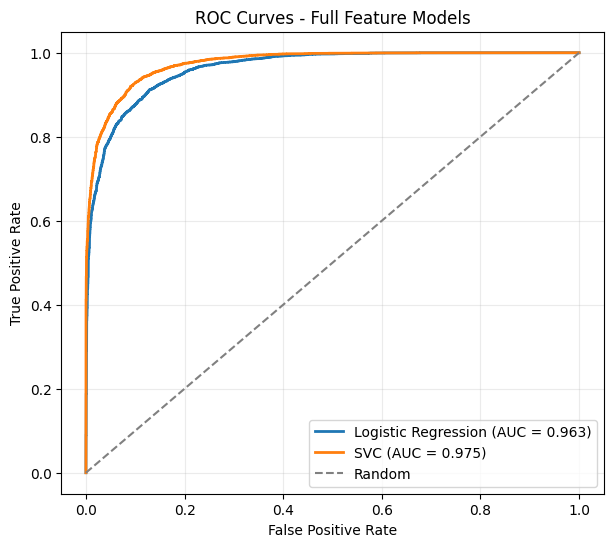

In [10]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Use probability scores from the full-feature experiment
fpr_lr, tpr_lr, _ = roc_curve(yf_test, proba_lr)
auc_lr = auc(fpr_lr, tpr_lr)

fpr_svc, tpr_svc, _ = roc_curve(yf_test, proba_svc)
auc_svc = auc(fpr_svc, tpr_svc)

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(fpr_lr, tpr_lr, color='tab:blue', linewidth=2,
        label=f'Logistic Regression (AUC = {auc_lr:.3f})')
ax.plot(fpr_svc, tpr_svc, color='tab:orange', linewidth=2,
        label=f'SVC (AUC = {auc_svc:.3f})')
ax.plot([0, 1], [0, 1], linestyle='--', color='grey', label='Random')

ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves - Full Feature Models')
ax.legend(loc='lower right')
ax.grid(alpha=0.25)
plt.show()

In [11]:
# Build comparison table with original test-set indices for manual inspection
import numpy as np

print(type(yf_test))
print(type(pred_lr))
print(type(pred_svc))

assert len(yf_test) == len(pred_lr) == len(pred_svc), 'Mismatched lengths between y_true and predictions'

model_predictions = pd.DataFrame({
    'y_true': yf_test.to_numpy(),
    'pred_lr': np.asarray(pred_lr),
    'pred_svc': np.asarray(pred_svc),
}, index=yf_test.index).sort_index()

# Helpful review flags
model_predictions['lr_correct'] = model_predictions['pred_lr'] == model_predictions['y_true']
model_predictions['svc_correct'] = model_predictions['pred_svc'] == model_predictions['y_true']

print(model_predictions.head(10))
print(model_predictions.isna().sum())

<class 'pandas.Series'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
    y_true  pred_lr  pred_svc  lr_correct  svc_correct
8        0        0         0        True         True
10       1        1         1        True         True
11       1        1         1        True         True
12       0        0         0        True         True
14       0        0         0        True         True
17       1        1         1        True         True
32       0        0         0        True         True
37       0        0         0        True         True
43       0        0         0        True         True
51       1        1         1        True         True
y_true         0
pred_lr        0
pred_svc       0
lr_correct     0
svc_correct    0
dtype: int64


In [12]:
# McNemar test setup: contingency table based on correctness of each model

# 2x2 contingency table
# rows: LR correct?   columns: SVC correct?
cm = pd.crosstab(model_predictions['lr_correct'], model_predictions['svc_correct'])
cm = cm.reindex(index=[True, False], columns=[True, False], fill_value=0)

print('McNemar contingency table (rows=LR, cols=SVC):')
print(cm)

# Off-diagonal cells used by McNemar
b = cm.loc[True, False]   # LR correct, SVC wrong
c = cm.loc[False, True]   # LR wrong, SVC correct
print(f'b (LR only correct): {b}')
print(f'c (SVC only correct): {c}')

McNemar contingency table (rows=LR, cols=SVC):
svc_correct  True   False
lr_correct               
True          8674    223
False          463    640
b (LR only correct): 223
c (SVC only correct): 463


In [13]:
from statsmodels.stats.contingency_tables import mcnemar

res = mcnemar(cm, exact=False, correction=True)
print(f"Stats: {res.statistic}")
print(f"p-value: {res.pvalue}")


Stats: 83.26676384839651
p-value: 7.169494283042488e-20


Perform bootstrap sampling to analyze the effect size

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score
import numpy as np

METRIC_FUNCS = {
    "accuracy": accuracy_score,
    "precision": precision_score,
    "recall": recall_score,
    "f1": f1_score,
}


def bootstrap_metric_delta_ci(
    df,
    metric="accuracy",
    n_resamples=1000,
    confidence_level=0.95,
    random_state=42,
):
    """Low-memory bootstrap CI for metric delta: LR - SVC.

    Keeps only a compact float array of bootstrap deltas and avoids
    retaining large intermediate bootstrap objects.
    """
    if metric not in METRIC_FUNCS:
        valid = ", ".join(METRIC_FUNCS)
        raise ValueError(f"Unsupported metric '{metric}'. Use one of: {valid}")

    score_fn = METRIC_FUNCS[metric]
    y_true = df["y_true"].to_numpy(dtype=np.int8)
    pred_lr = df["pred_lr"].to_numpy(dtype=np.int8)
    pred_svc = df["pred_svc"].to_numpy(dtype=np.int8)

    if not (len(y_true) == len(pred_lr) == len(pred_svc)):
        raise ValueError("Input columns y_true, pred_lr, pred_svc must have same length")

    def statistic(y, lr, svc):
        return score_fn(y, lr, zero_division=0) - score_fn(y, svc, zero_division=0)

    rng = np.random.default_rng(random_state)
    n = y_true.shape[0]
    deltas = np.empty(n_resamples, dtype=np.float32)

    for i in range(n_resamples):
        idx = rng.integers(0, n, n)
        deltas[i] = statistic(y_true[idx], pred_lr[idx], pred_svc[idx])

    alpha = 1.0 - confidence_level
    ci_low = float(np.quantile(deltas, alpha / 2.0))
    ci_high = float(np.quantile(deltas, 1.0 - alpha / 2.0))
    point_estimate = float(statistic(y_true, pred_lr, pred_svc))
    p_two_sided = float(2.0 * min((deltas <= 0).mean(), (deltas >= 0).mean()))

    return {
        "metric": metric,
        "point_estimate": point_estimate,
        "ci_low": ci_low,
        "ci_high": ci_high,
        "p_value_two_sided": p_two_sided,
        "n_resamples": n_resamples,
        "random_state": random_state,
    }


accuracy_delta = bootstrap_metric_delta_ci(model_predictions, metric="accuracy")
accuracy_delta